In [1]:
%load_ext autoreload
%autoreload 2

In [74]:
import sys, os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from NNMFit.utilities import ScanHandler

# import plotting utils
sys.path.append( "/data/user/tvaneede/utils" )
from FlavourScansPlotting import get_contour_points, get_contour_points_multiple_scans

# import scanning points
import pickle

df_points = {}

with open('/data/user/tvaneede/GlobalFit/custom_scan_flavor/default_custom_scan_points_flavor_fine.pickle', 'rb') as f:
    x = pickle.load(f)

# Create DataFrame
df_points["fine"] = pd.DataFrame({
    'astro_nue_ratio': x["astro_nue_ratio"],
    'astro_nutau_ratio': x["astro_nutau_ratio"],
    'fe': x["astro_nue_ratio"]/(1 +  x["astro_nue_ratio"] + x["astro_nutau_ratio"]),
    'fmu': 1/(1 +  x["astro_nue_ratio"] + x["astro_nutau_ratio"]),
    'ftau': x["astro_nutau_ratio"]/(1 +  x["astro_nue_ratio"] + x["astro_nutau_ratio"]),
})

with open('/data/user/tvaneede/GlobalFit/custom_scan_flavor/default_custom_scan_points_flavor_fine_center.pickle', 'rb') as f:
    x = pickle.load(f)

# Create DataFrame
df_points["center"] = pd.DataFrame({
    'astro_nue_ratio': x["astro_nue_ratio"],
    'astro_nutau_ratio': x["astro_nutau_ratio"],
    'fe': x["astro_nue_ratio"]/(1 +  x["astro_nue_ratio"] + x["astro_nutau_ratio"]),
    'fmu': 1/(1 +  x["astro_nue_ratio"] + x["astro_nutau_ratio"]),
    'ftau': x["astro_nutau_ratio"]/(1 +  x["astro_nue_ratio"] + x["astro_nutau_ratio"]),
})

# import plotting flavor triangle
sys.path.append( "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks" )
from plot_utils_triangle import *

# dict with all my dag scans
from scan_dict import scan_dir_dict

In [3]:
plotting_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/debug_minimizer/systematics"
os.system(f"mkdir -p {plotting_path}")

0

In [75]:
def study_contour( scan_dirs, drop_unsuccessful = False, N_grid = 20, levels = ['68%','90%'],plot_points = None ):

    scan_dict = {}
    data = {}

    for i, scan_dir in enumerate(scan_dirs):
        name = i
        data[name] = {}
        scan_dict[name] = ScanHandler(scan_dir,dump=False,drop_unsuccessful=drop_unsuccessful)
        data[name]["ftau"],data[name]["fe"],data[name]["ts"],data[name]["ftau_grid"],data[name]["fe_grid"],data[name]["ts_grid"] = get_contour_points(scan_dict,name, N_grid = N_grid)

    if len(scan_dirs) > 1:
        name = "combined"
        data[name] = {}
        data[name]["ftau"],data[name]["fe"],data[name]["ts"],data[name]["ftau_grid"],data[name]["fe_grid"],data[name]["ts_grid"] = get_contour_points_multiple_scans(scan_dict,scan_dict.keys(), N_grid = N_grid)

    # Create a 2D histogram for the heatmap
    heatmap, xedges, yedges = np.histogram2d( data[name]["ftau"], data[name]["fe"], bins=50, range=[[0, 1], [0, 1]])

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 8))

    if plot_points:
        ax.scatter( df_points[plot_points]["ftau"],df_points[plot_points]["fe"], color = "red" )

    # sc = ax.scatter(df["ftau"],df["fe"],c=df["dllh"],cmap="coolwarm",alpha=0.6,edgecolors="none",s=25)
    sc = ax.scatter(data[name]["ftau"],data[name]["fe"],c=data[name]["ts"],cmap="coolwarm",alpha=0.6,edgecolors="none",s=25)
    
    ts_dict = {'68%' : 2.37,'90%' : 4.605,'95%' : 5.99}

    ts_values = [ts_dict[i] for i in levels]

    C2 = ax.contour(data[name]["ftau_grid"],data[name]["fe_grid"],data[name]["ts_grid"],  ts_values,linestyles=["-",'--'],linewidths=3,colors='black')

    # Annotate each point with its dllh value
    for i in range(len(data[name]["ftau"])):
        ax.annotate(
            f"{data[name]['ts'][i]:.2f}",  # Format dllh to 2 decimal places
            (data[name]["ftau"][i], data[name]["fe"][i]),
            fontsize=8,
            textcoords="offset points",
            xytext=(10, 5),  # Offset the text slightly from the point
            ha='left'
        )

    fig.colorbar(sc, ax=ax, label="dllh")

    # Add labels and title
    ax.set_title("2D Heatmap of fe vs. fmu with dllh as Color")
    ax.set_xlabel("ftau")
    ax.set_ylabel("fe")
    ax.grid(True)

    plt.show()

    return data


HESE

compare_syst_hese_HESEBestfit_SPL: a couple of fits completed succesfully with a dllh > 100. 

Actions: 
- I retry with more scan points.

Possible causes:
- Not enough statistics in HESE gradients?

removed stuff


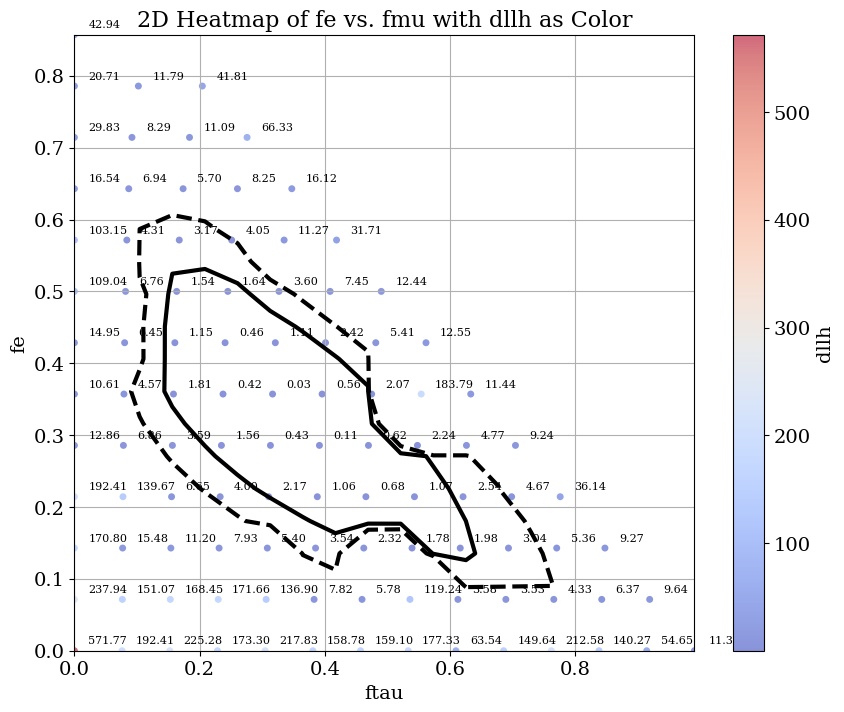

In [62]:
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/systematics/first_try/hese_HESEBestfit_SPL_noinel/"
log_dir = "/scratch/tvaneede/NNMFit/condor/19_03_2026_18_42_57"

data = study_contour( scan_dirs = [scan_dir], drop_unsuccessful=True, N_grid = 20, levels = ['68%','90%'], plot_points=None )

In [65]:
df = data[0]
cut = (df["ts"] > 100) & (df["ftau"] > 0.5) & (df["ftau"] < 0.6) & (df["fe"] > 0.35)

df[cut]

TypeError: unhashable type: 'Series'

/scratch/tvaneede/NNMFit/condor/19_03_2026_18_42_57/logs/astro_nue_ratio_p4_0080_astro_nutau_ratio_p6_2144.err

INFO:NNMFit.core.nnm_fitter: Adding gaussian noise to the fit variable seeds (2026-03-19 13:59:41; nnm_fitter.py:271)
INFO:NNMFit.core.nnm_fitter: Setting fit variable astro_norm to 1.8669710773866595 for minimizer seed with fixed parameters (2026-03-19 13:59:41; nnm_fitter.py:171)
INFO:NNMFit.core.nnm_fitter: Setting fit variable astro_nue_ratio to 4.008016032064129 for minimizer seed with fixed parameters (2026-03-19 13:59:41; nnm_fitter.py:171)
INFO:NNMFit.core.nnm_fitter: Setting fit variable astro_nutau_ratio to 6.214428857715434 for minimizer seed with fixed parameters (2026-03-19 13:59:41; nnm_fitter.py:171)
INFO:NNMFit.core.nnm_fitter: Setting fit variable gamma_astro to 2.8660815085822833 for minimizer seed with fixed parameters (2026-03-19 13:59:41; nnm_fitter.py:171)

Fit result is: (91.89293762523707, {'astro_norm': 1.8497122583010377, 'gamma_astro': 3.0167321942966727, 'CR_grad': 0.0018069493319134385, 'barr_h': -0.000628607077955536, 'barr_w': -0.001059748023981164, 'barr_y': -0.0015279854595877987, 'barr_z': -0.00276745787734302, 'conv_norm': 0.901559468711488, 'delta_gamma': 0.0005152090625113499, 'inel_scale': 1.0775277803643943, 'prompt_norm': 0.4650462930772848, 'muongun_norm': 1.0600044957932337, 'dom_eff': 1.0066511599805834, 'ice_abs': 1.0179659312912397, 'ice_scat': 0.9659552268367462, 'ice_holep0': 0.22676149450571595, 'ice_holep1': -0.046764346018725506, 'ice_crystal': 0.9748050560298256}, {'success': True, 'message': 'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH', 'nfev': 58, 'nit': 9, 'warnflag': 0})
Wrote fit-result to /data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit//hese//Poisson/hese_HESEBestfit_SPL_noinel/FitRes_astro_nue_ratio_p4_0080_astro_nutau_ratio_p6_2144.pickle

Retry with more points

/scratch/tvaneede/NNMFit/condor/23_03_2026_13_29_30/logs/astro_nue_ratio_p4_0080_astro_nutau_ratio_p6_2144.err 

INFO:NNMFit.core.nnm_fitter: Adding gaussian noise to the fit variable seeds (2026-03-23 08:46:23; nnm_fitter.py:271)
INFO:NNMFit.core.nnm_fitter: Setting fit variable astro_norm to 2.090841074412994 for minimizer seed with fixed parameters (2026-03-23 08:46:23; nnm_fitter.py:171)
INFO:NNMFit.core.nnm_fitter: Setting fit variable astro_nue_ratio to 4.008016032064129 for minimizer seed with fixed parameters (2026-03-23 08:46:23; nnm_fitter.py:171)
INFO:NNMFit.core.nnm_fitter: Setting fit variable astro_nutau_ratio to 6.214428857715434 for minimizer seed with fixed parameters (2026-03-23 08:46:23; nnm_fitter.py:171)
INFO:NNMFit.core.nnm_fitter: Setting fit variable gamma_astro to 2.8014234402628992 for minimizer seed with fixed parameters (2026-03-23 08:46:23; nnm_fitter.py:171)
INFO:NNMFit.core.nnm_fitter: Setting fit variable CR_grad to 0.0 for minimizer seed with fixed parameters (2026-03-23 08:46:23; nnm_fitter.py:171)

Fit result is: (2.4812169333542746, {'astro_norm': 0.46068376306340303, 'gamma_astro': 2.782118869219503, 'CR_grad': -0.16971119397009315, 'barr_h': 0.0021854325964290305, 'barr_w': 0.021292417332498512, 'barr_y': 0.06086562121353541, 'barr_z': 0.03120769923215826, 'conv_norm': 1.0338826653518352, 'delta_gamma': -0.0009057154276774612, 'inel_scale': 1.0099792973600423, 'prompt_norm': 0.5045731197479565, 'muongun_norm': 1.0820215759173093, 'dom_eff': 1.0022396998934229, 'ice_abs': 0.9973095204555745, 'ice_scat': 1.0006411764659775, 'ice_holep0': 0.2437317637526592, 'ice_holep1': -0.057489791325926014, 'ice_crystal': 1.002329154015661}, {'success': True, 'message': 'CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL', 'nfev': 1922, 'nit': 932, 'warnflag': 0})
Wrote fit-result to /data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit//hese/systematics/first_try/hese_HESEBestfit_SPL_noinel_fine/FitRes_astro_nue_ratio_p4_0080_astro_nutau_ratio_p6_2144.pickle
Full execution took 1010.7616353034973 seconds

removed stuff


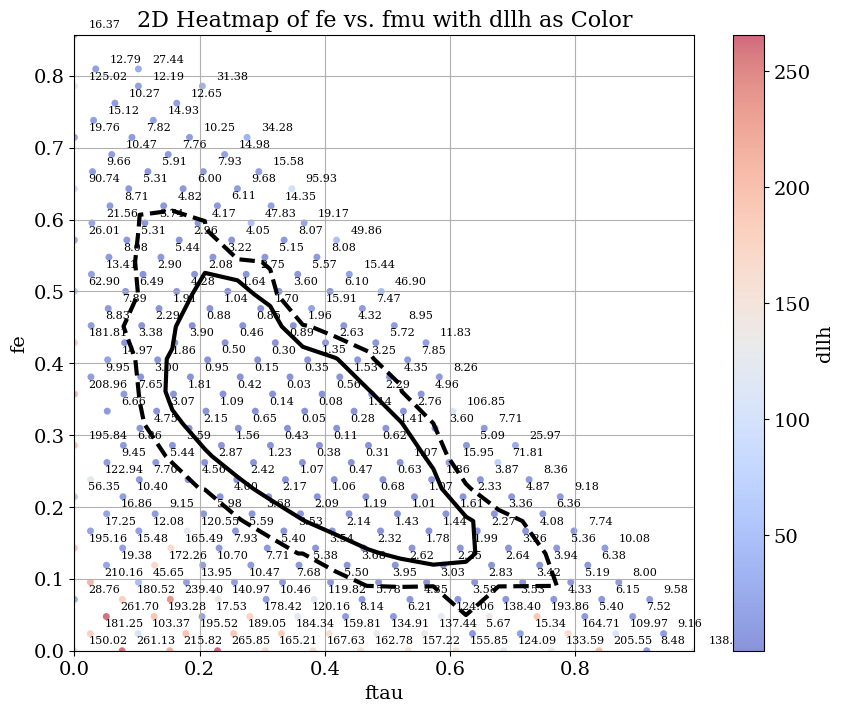

In [72]:
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/systematics/first_try/hese_HESEBestfit_SPL_noinel_fine_0/"
log_dir = "/scratch/tvaneede/NNMFit/condor/23_03_2026_13_29_30"

df = study_contour( scan_dirs = [scan_dir], drop_unsuccessful=True, N_grid = 20, levels = ['68%','90%'], plot_points=None )

Now trying to merge two scans

/scratch/tvaneede/NNMFit/condor/23_03_2026_13_29_30/logs/astro_nue_ratio_p9_9258_astro_nutau_ratio_p3_4495.err

INFO:NNMFit.core.nnm_fitter: Adding gaussian noise to the fit variable seeds (2026-03-23 08:50:58; nnm_fitter.py:271)
INFO:NNMFit.core.nnm_fitter: Setting fit variable astro_norm to 1.8315273055690948 for minimizer seed with fixed parameters (2026-03-23 08:50:58; nnm_fitter.py:171)
INFO:NNMFit.core.nnm_fitter: Setting fit variable astro_nue_ratio to 9.925841414717619 for minimizer seed with fixed parameters (2026-03-23 08:50:58; nnm_fitter.py:171)
INFO:NNMFit.core.nnm_fitter: Setting fit variable astro_nutau_ratio to 3.449515116942383 for minimizer seed with fixed parameters (2026-03-23 08:50:58; nnm_fitter.py:171)
INFO:NNMFit.core.nnm_fitter: Setting fit variable gamma_astro to 2.476236029404414 for minimizer seed with fixed parameters (2026-03-23 08:50:58; nnm_fitter.py:171)

Fit result is: (7.4901040011231785, {'astro_norm': 0.2778870357307449, 'gamma_astro': 2.756687882424212, 'CR_grad': -0.19068674618777798, 'barr_h': 0.0026962603794545084, 'barr_w': 0.025436891199543246, 'barr_y': 0.07385897451774676, 'barr_z': 0.03801277452216112, 'conv_norm': 1.0410649317846707, 'delta_gamma': -0.0012993700277164517, 'inel_scale': 1.0128985674394126, 'prompt_norm': 1.1797434885037152, 'muongun_norm': 1.1400741299668113, 'dom_eff': 1.0066498187469144, 'ice_abs': 0.9965666489809814, 'ice_scat': 1.0012403271517114, 'ice_holep0': 0.25007547023594956, 'ice_holep1': -0.05720690833549883, 'ice_crystal': 1.0044898352506066}, {'success': True, 'message': 'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH', 'nfev': 1519, 'nit': 1035, 'warnflag': 0})
Wrote fit-result to /data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit//hese/systematics/first_try/hese_HESEBestfit_SPL_noinel_fine/FitRes_astro_nue_ratio_p9_9258_astro_nutau_ratio_p3_4495.pickle
Full execution took 676.6872012615204 seconds

/scratch/tvaneede/NNMFit/condor/23_03_2026_14_29_20/logs/astro_nue_ratio_p9_9258_astro_nutau_ratio_p3_4495.err

INFO:NNMFit.core.nnm_fitter: Adding gaussian noise to the fit variable seeds (2026-03-23 09:44:49; nnm_fitter.py:271)
INFO:NNMFit.core.nnm_fitter: Setting fit variable astro_norm to 1.4782376390549978 for minimizer seed with fixed parameters (2026-03-23 09:44:49; nnm_fitter.py:171)
INFO:NNMFit.core.nnm_fitter: Setting fit variable astro_nue_ratio to 9.925841414717619 for minimizer seed with fixed parameters (2026-03-23 09:44:49; nnm_fitter.py:171)
INFO:NNMFit.core.nnm_fitter: Setting fit variable astro_nutau_ratio to 3.449515116942383 for minimizer seed with fixed parameters (2026-03-23 09:44:49; nnm_fitter.py:171)
INFO:NNMFit.core.nnm_fitter: Setting fit variable gamma_astro to 3.1258848765479357 for minimizer seed with fixed parameters (2026-03-23 09:44:49; nnm_fitter.py:171)

Fit result is: (5.422577243170069, {'astro_norm': 0.27916195666763716, 'gamma_astro': 2.7610566158519867, 'CR_grad': -0.18771986939810759, 'barr_h': 0.002721826638454188, 'barr_w': 0.025688114840470396, 'barr_y': 0.07444379210969031, 'barr_z': 0.03828464137448894, 'conv_norm': 1.0414066111505, 'delta_gamma': -0.001329729055873417, 'inel_scale': 1.0130838210439688, 'prompt_norm': 1.186830416993922, 'muongun_norm': 1.1418745390640597, 'dom_eff': 1.0031526397468604, 'ice_abs': 0.9954763688314116, 'ice_scat': 0.9998143362924029, 'ice_holep0': 0.24128639797275758, 'ice_holep1': -0.05687266641645803, 'ice_crystal': 0.998117752418964}, {'success': True, 'message': 'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH', 'nfev': 2911, 'nit': 1950, 'warnflag': 0})
Wrote fit-result to /data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit//hese/systematics/first_try/hese_HESEBestfit_SPL_noinel_fine_1/FitRes_astro_nue_ratio_p9_9258_astro_nutau_ratio_p3_4495.pickle

removed stuff


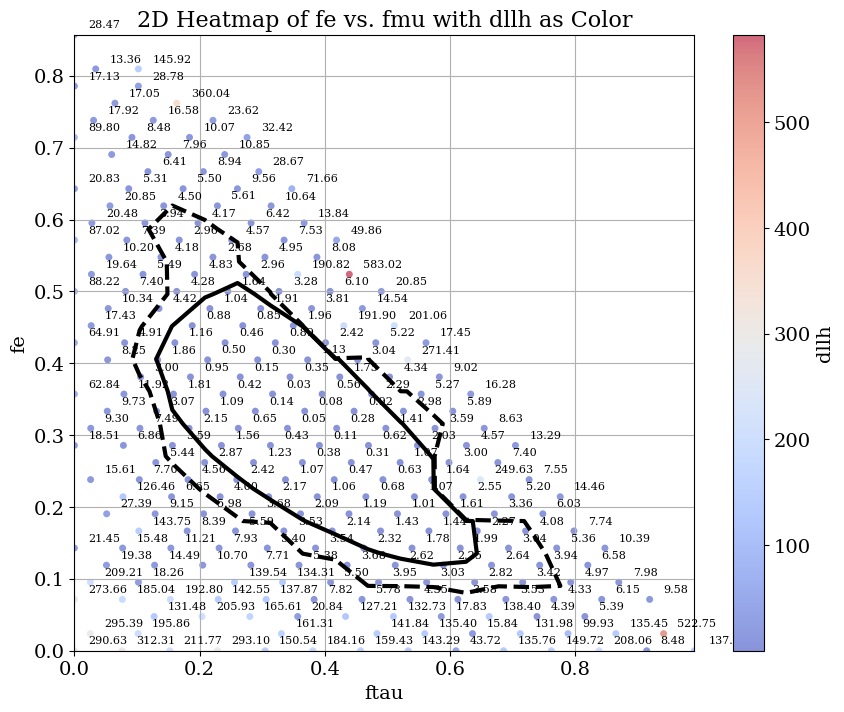

In [36]:
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/systematics/first_try/hese_HESEBestfit_SPL_noinel_fine_1/"
log_dir = "/scratch/tvaneede/NNMFit/condor/23_03_2026_13_29_30"

df = study_contour( scan_dir = scan_dir, drop_unsuccessful=True, N_grid = 20, levels = ['68%','90%'], plot_points=None )

removed stuff
removed stuff
removed stuff


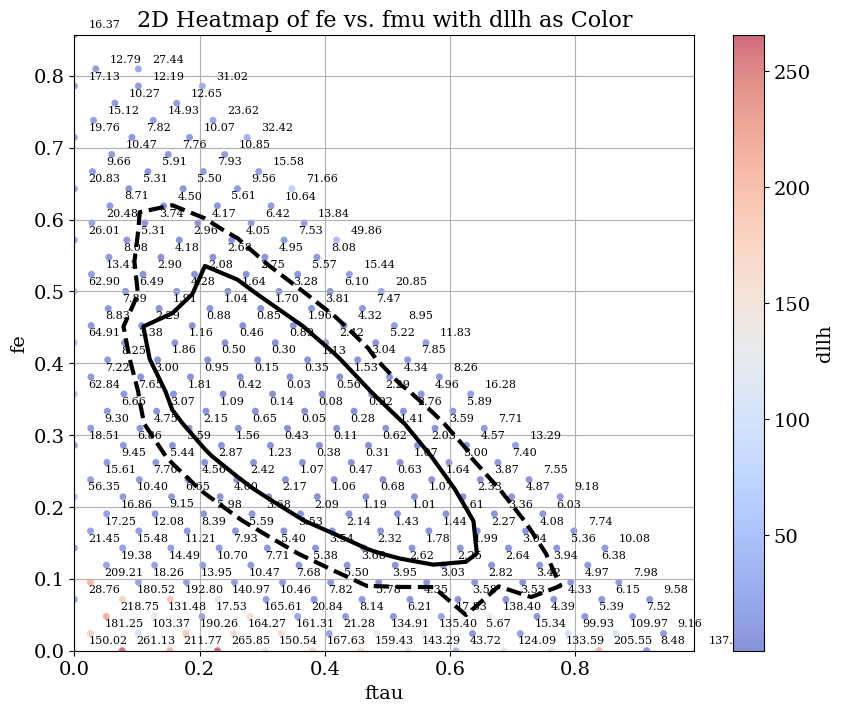

In [76]:
scan_dirs = ["/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/systematics/first_try/hese_HESEBestfit_SPL_noinel_fine_0/",
             "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/systematics/first_try/hese_HESEBestfit_SPL_noinel_fine_1/"]

df = study_contour( scan_dirs = scan_dirs, drop_unsuccessful=True, N_grid = 20, levels = ['68%','90%'], plot_points=None )

removed stuff


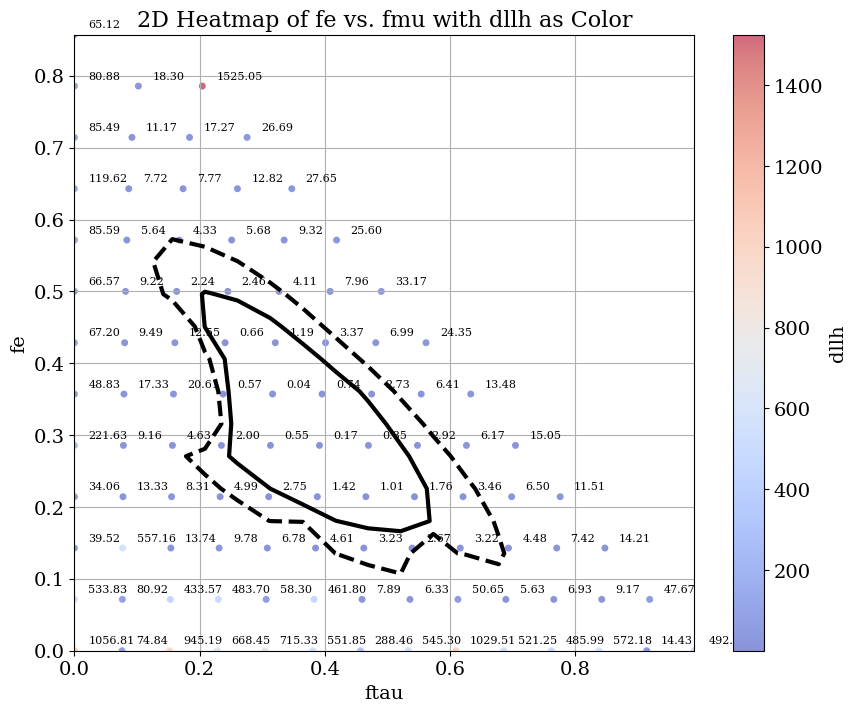

In [28]:
scan_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/systematics/first_try/hese_SPL_noinel/"
log_dir = "/scratch/tvaneede/NNMFit/condor/19_03_2026_18_43_01"

df = study_contour( scan_dir = scan_dir, drop_unsuccessful=True, N_grid = 20, levels = ['68%','90%'], plot_points=None )

Extra tests

In [85]:
mask = (df["fe"] > 0.4) & (df["fe"] < 0.5) & (df["ftau"] > 0.1) & (df["ftau"] < 0.2)
# mask = df["fe"] >= 0.
df["dllh-llh"] =  df["llh"] - df["dllh"]/2
df[mask][["fe","ftau","fmu","llh","dllh","dllh-llh","fit_success"]]
df[mask].iloc[0]


CR_grad               0.119945
astro_norm             2.04303
astro_nue_ratio       1.042701
astro_nutau_ratio     0.390268
barr_h               -0.011476
barr_w                0.282672
barr_y                -0.11791
barr_z               -0.099674
conv_norm             1.070931
delta_gamma          -0.043775
e_break                    3.5
effective_veto        0.814133
fit_success                1.0
gamma_1                    3.0
gamma_2               2.582893
llh                  14.632108
muon_norm             1.001877
muongun_norm          0.994445
prompt_norm                0.0
dllh                 29.264216
fe                    0.428571
fmu                    0.41102
ftau                  0.160408
dllh-llh                   0.0
Name: 58, dtype: Float64

In [68]:
# Assuming data[name] contains the grids
fe_grid = data[name]["fe_grid"]
ftau_grid = data[name]["ftau_grid"]
ts_grid = data[name]["ts_grid"]

# Repeat fe and ftau to match the length of the flattened TS_gridded
fe_repeated = np.repeat(fe_grid, len(ftau_grid))
ftau_tiled = np.tile(ftau_grid, len(fe_grid))

# Flatten TS_gridded
ts_flattened = ts_grid.ravel()

# Create DataFrame
df = pd.DataFrame({
    'fe': fe_repeated,
    'ftau': ftau_tiled,
    'fmu': 1-fe_repeated-ftau_tiled,
    'ts': ts_flattened
})

In [72]:

mask = (df["fe"] > 0.4) & (df["fe"] < 0.5) & (df["fmu"] > 0.4) & (df["fmu"] < 0.5)
df[mask][["fe","fmu","ts"]]

,fe,fmu,ts
423,0.413793,0.483793,14.007754
424,0.413793,0.449655,20.963405
425,0.413793,0.415517,24.434665
452,0.443350,0.488374,13.791912
453,0.443350,0.454236,15.832011
454,0.443350,0.420099,22.787662
481,0.472906,0.492956,17.567938
482,0.472906,0.458818,10.803601
483,0.472906,0.424680,12.600468
